# 🛠️ Parte 2: Engenharia de Features e Modelagem Preditiva

Neste notebook, transformaremos a série temporal em um problema de Aprendizado Supervisório e treinaremos modelos para prever a demanda diária de energia elétrica.

---

## 1. Importação das Bibliotecas

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

# Configuração gráfica
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Engenharia de Features (Feature Engineering)

Para ensinar modelos de Machine Learning a capturar a dinâmica da série temporal, criaremos:
* **Features Temporais**: Mês, dia da semana, dia do ano e indicador de fim de semana.
* **Lags (Defasagens)**: Valores passados ($t-1, t-2, t-7, t-14, t-30$).
* **Estatísticas Móveis**: Média e desvio padrão dos últimos 7 e 30 dias.

In [2]:
# Importando os dados do notebook anterior (usando a mesma seed)
def carregar_dados():
    np.random.seed(42)
    datas = pd.date_range(start="2023-01-01", end="2025-12-31", freq="D")
    n = len(datas)
    tendencia = np.linspace(100, 250, n)
    sazonalidade_anual = 30 * np.sin(2 * np.pi * datas.dayofyear / 365)
    sazonalidade_semanal = 15 * np.sin(2 * np.pi * datas.dayofweek / 7)
    ruido = np.random.normal(0, 8, n)
    df = pd.DataFrame({"data": datas, "consumo_mwh": tendencia + sazonalidade_anual + sazonalidade_semanal + ruido})
    df.set_index("data", inplace=True)
    return df

df = carregar_dados()

# 1. Features Calendáricas
df["dia_da_semana"] = df.index.dayofweek
df["mes"] = df.index.month
df["dia_do_ano"] = df.index.dayofyear
df["eh_fim_de_semana"] = (df["dia_da_semana"] >= 5).astype(int)

# 2. Lags Temporais
for lag in [1, 2, 7, 14, 30]:
    df[f"lag_{lag}"] = df["consumo_mwh"].shift(lag)

# 3. Janelas Móveis (Rolling Statistics)
df["media_movel_7d"] = df["consumo_mwh"].shift(1).rolling(window=7).mean()
df["std_movel_7d"] = df["consumo_mwh"].shift(1).rolling(window=7).std()
df["media_movel_30d"] = df["consumo_mwh"].shift(1).rolling(window=30).mean()

# Remover linhas com valores nulos resultantes dos lags
df_modelo = df.dropna().copy()
print(f"Dimensão do dataset após Engenharia de Features: {df_modelo.shape}")
df_modelo.head()

Dimensão do dataset após Engenharia de Features: (1066, 13)


,consumo_mwh,dia_da_semana,mes,dia_do_ano,eh_fim_de_semana,lag_1,lag_2,lag_7,lag_14,lag_30,media_movel_7d,std_movel_7d,media_movel_30d
data,,,,,,,,,,,,,
2023-01-31,126.283537,1,1,31,0,116.452319,101.665050,115.524811,114.471077,92.762642,112.971029,10.170431,107.912666
2023-02-01,149.391188,2,2,32,0,126.283537,116.452319,126.072336,128.614301,100.063520,114.507990,11.363621,109.030029
2023-02-02,126.923995,3,2,33,0,149.391188,126.283537,123.803562,111.347907,118.731543,117.839254,17.225047,110.674285
2023-02-03,106.123664,4,2,34,0,126.923995,149.391188,101.292319,94.921741,129.283189,118.285030,17.444111,110.947367
2023-02-04,113.615028,5,2,35,1,106.123664,126.923995,105.986804,110.451281,107.761918,118.975222,16.741137,110.175383


## 3. Divisão em Treino e Teste (Respeitando a Ordem Cronológica)

Diferente da validação cruzada tradicional, em séries temporais o conjunto de **teste** deve obrigatoriamente ser a parte final do tempo (futuro), evitando *data leakage* (vazamento de dados).

In [3]:
# Definindo 80% dos dados para treino e 20% para teste
tamanho_treino = int(len(df_modelo) * 0.8)

treino = df_modelo.iloc[:tamanho_treino]
teste = df_modelo.iloc[tamanho_treino:]

X_colunas = [c for c in df_modelo.columns if c != "consumo_mwh"]
y_coluna = "consumo_mwh"

X_treino, y_treino = treino[X_colunas], treino[y_coluna]
X_teste, y_teste = teste[X_colunas], teste[y_coluna]

print(f"Período de Treino: {treino.index.min().strftime('%Y-%m-%d')} até {treino.index.max().strftime('%Y-%m-%d')}")
print(f"Período de Teste:  {teste.index.min().strftime('%Y-%m-%d')} até {teste.index.max().strftime('%Y-%m-%d')}")

Período de Treino: 2023-01-31 até 2025-05-31
Período de Teste:  2025-06-01 até 2025-12-31


## 4. Treinamento e Avaliação de Modelos

Treinaremos e compararemos dois modelos distintos:
1. **Regressão Ridge (Linear com Regularização L2)**
2. **XGBoost Regressor (Gradient Boosted Decision Trees)**

In [4]:
# Inicializando e treinando os modelos
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_treino, y_treino)
pred_ridge = modelo_ridge.predict(X_teste)

modelo_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
modelo_xgb.fit(X_treino, y_treino)
pred_xgb = modelo_xgb.predict(X_teste)

# Função para calcular e exibir métricas
def avaliar_modelo(nome, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    print(f"=== {nome} ===")
    print(f"RMSE: {rmse:.3f} MWh")
    print(f"MAE:  {mae:.3f} MWh")
    print(f"MAPE: {mape:.2f}%\n")
    return {"Modelo": nome, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape}

resultados = []
resultados.append(avaliar_modelo("Regressão Ridge", y_teste, pred_ridge))
resultados.append(avaliar_modelo("XGBoost Regressor", y_teste, pred_xgb))

df_resultados = pd.DataFrame(resultados)
df_resultados

=== Regressão Ridge ===
RMSE: 8.651 MWh
MAE:  7.130 MWh
MAPE: 3.25%

=== XGBoost Regressor ===
RMSE: 10.962 MWh
MAE:  8.794 MWh
MAPE: 4.07%



,Modelo,RMSE,MAE,MAPE (%)
0,Regressão Ridge,8.650902,7.130458,3.251583
1,XGBoost Regressor,10.961702,8.793947,4.072477


## 5. Comparação Visual: Valor Real vs. Previsões

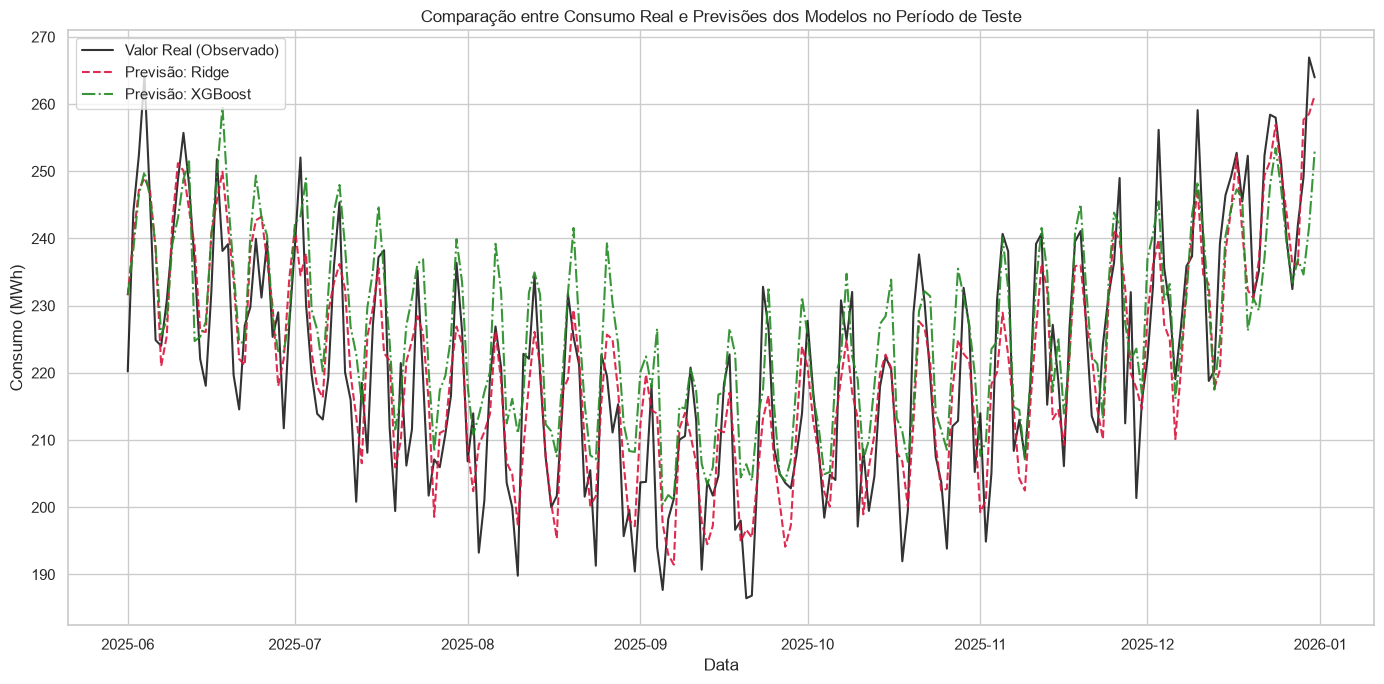

In [5]:
plt.figure(figsize=(14, 7))
plt.plot(y_teste.index, y_teste, label="Valor Real (Observado)", color="black", alpha=0.8, linewidth=1.5)
plt.plot(y_teste.index, pred_ridge, label="Previsão: Ridge", color="crimson", linestyle="--", alpha=0.9)
plt.plot(y_teste.index, pred_xgb, label="Previsão: XGBoost", color="forestgreen", linestyle="-.", alpha=0.9)

plt.title("Comparação entre Consumo Real e Previsões dos Modelos no Período de Teste")
plt.xlabel("Data")
plt.ylabel("Consumo (MWh)")
plt.legend(loc="upper left")
plt.tight_layout()

plt.savefig("comparacao_previsoes_modelos.png", dpi=300)
plt.show()